# Chapter 3a: Pretraining a Base Model

In Chapter 2 we trained a ~17.6M model on TinyStories and it produced toddler-grade stories. That proved the *machinery* works. This chapter takes the **same architecture** and scales it into something that has actually read real English — a **base model** we can later turn into a chat assistant (Chapter 3b).

> **Two-stage map.** You cannot fine-tune a chat model out of nothing. First **pretrain** (this notebook): show the model billions of tokens of plain text so it learns grammar, facts, and how language flows. Then **SFT** (3b): show it a few thousand `instruction → response` examples so it learns the *shape* of a conversation. SFT teaches *format and style*, not knowledge — the knowledge has to already be in the base. That's why we pretrain first.

### What is genuinely new here vs Chapter 2

The GPT model code (`CausalSelfAttention`, `Block`, `GPT`) is **unchanged** — you already built and understood it in Ch.2, so here it's *given* in full (not a TODO). What's new is everything around it that turns a toy run into a real one:

| New concept | Why it didn't matter in Ch.2 | Why it matters now |
|---|---|---|
| **Streaming + binary token cache** | TinyStories fit in RAM | FineWeb-Edu is multi-TB; you stream a slice and cache tokens to disk |
| **Mixed precision (AMP)** | tiny model, fit easily | a 50M model in fp32 + activations blows past 8GB; fp16/bf16 halves it |
| **Gradient checkpointing** | not needed | trades compute for memory so deeper/wider fits |
| **LR warmup + cosine decay** | flat LR was fine for 2000 steps | long runs diverge early and waste late steps without a schedule |
| **Checkpoint save/resume** | run finished in 2.3 min | a multi-hour run *must* survive a crash or a closed lid |

### Target model

`d_model=512, n_heads=8, d_ff=2048, n_layers=8, block_size=256` → **~50M params** (with weight tying). Fits 8GB with AMP + a modest batch size. Pretrains in a few hours on the RTX 4060 Ti over ~1–2B tokens of FineWeb-Edu.

**Pattern unchanged:** each phase = concept → `TODO` stub for you to implement → a `# check` cell that fails loudly if the logic is wrong.

## 0. Setup

Same imports as Ch.2 plus `numpy` (for the on-disk token array) and `os` (paths). The `Config` dataclass just collects hyperparameters in one place so the rest of the notebook reads `cfg.d_model` instead of magic numbers.

In [1]:
import math
import os
import time
from dataclasses import dataclass

import numpy as np
import tiktoken
import torch
import torch.nn.functional as F
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))
    # bf16 is safe on Ampere+ (RTX 4060 Ti is Ada). We use it below; see Phase 3.
    print("bf16 supported:", torch.cuda.is_bf16_supported())
    # Free throughput on Ada: allow TF32 in matmuls, and let cuDNN autotune kernels for our
    # fixed (batch, block) shapes. TF32 keeps fp32's range with ~10-bit mantissa -- negligible
    # effect on LM training, real speedup on the tensor cores. benchmark=True pays a one-time
    # autotune cost on the first step, then reuses the fastest kernels.
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True

DATA_DIR = "data"          # token cache + checkpoints live here
os.makedirs(DATA_DIR, exist_ok=True)

enc = tiktoken.get_encoding("gpt2")
EOT = enc.eot_token        # 50256 = <|endoftext|>, used to separate documents
VOCAB_SIZE = enc.n_vocab   # 50257


@dataclass
class Config:
    vocab_size: int = VOCAB_SIZE
    d_model: int = 512
    n_heads: int = 8
    d_ff: int = 2048
    n_layers: int = 8
    block_size: int = 256
    dropout: float = 0.0      # pretraining on lots of data: dropout usually 0 (you won't see a sample twice)

cfg = Config()
cfg

device: cuda
gpu: NVIDIA GeForce RTX 4060 Ti
bf16 supported: True


Config(vocab_size=50257, d_model=512, n_heads=8, d_ff=2048, n_layers=8, block_size=256, dropout=0.0)

## 1. Data — stream FineWeb-Edu and cache tokens to disk

**The dataset.** [FineWeb-Edu](https://huggingface.co/datasets/HuggingFaceFW/fineweb-edu) is filtered, high-quality educational English web text — the same corpus SmolLM2 was pretrained on. The full thing is multi-terabyte. We use the `sample-10BT` config (a 10-billion-token sample) and **stream** it: download examples one at a time over the network, never the whole file.

**Why a binary token cache (`.bin`).** Tokenizing is slow (CPU-bound BPE). You do *not* want to re-tokenize every epoch. So we tokenize **once**, write the token ids to a flat file on disk, then `delete the raw text`. Training reads tokens straight from that file.

**Why `np.memmap` + `uint16`.**
- `uint16` holds 0–65535; our max token id is 50256, so every token fits in **2 bytes**. (Using int64 would waste 4× the disk.)
- `memmap` maps the file into memory *lazily* — the OS pages in only the slices you touch. So a multi-GB token file "fits in RAM" even when it doesn't: you never load it all at once.

**The token-budget math** (from the handoff): 1 token ≈ 2 bytes here, so 1B tokens ≈ 2GB on disk. Pick a budget you can afford and *stop the stream* when you hit it — that's the whole point of streaming.

**Particularity — document separators.** Web docs are independent. If you just concatenate them, the model learns to run one article straight into the next. We append `EOT` (`<|endoftext|>`) after each document so the model learns "this is where a piece of text ends."

| variable | shape / type | meaning |
|---|---|---|
| `ids` | list[int] | token ids for one document, from `enc.encode_ordinary(text)` |
| token budget | int | total tokens to write before stopping the stream |
| `.bin` file | uint16 on disk | flat array of all tokens, documents joined by `EOT` |

In [2]:
from datasets import load_dataset


def build_token_cache(path, token_budget, split_name="sample-10BT"):
    """Stream FineWeb-Edu, tokenize, write a flat uint16 .bin of length ~token_budget.

    Skips work entirely if `path` already exists (tokenizing is expensive -- do it once).
    """
    if os.path.exists(path):
        n = os.path.getsize(path) // 2  # 2 bytes per uint16 token
        print(f"{path} already exists ({n:,} tokens) -- skipping rebuild")
        return path

    ds = load_dataset("HuggingFaceFW/fineweb-edu", name=split_name,
                      split="train", streaming=True)

    arr = np.memmap(path, dtype=np.uint16, mode="w+", shape=(token_budget,))
    written = 0
    t0 = time.time()
    for doc in ds:
        ids = enc.encode_ordinary(doc["text"])   # encode_ordinary ignores special tokens in text
        ids.append(EOT)                          # document separator
        take = ids[: token_budget - written]
        arr[written : written + len(take)] = take
        written += len(take)
        if written >= token_budget: 
            break
        if written % 5_000_000 < len(take):  # progress every ~5M tokens
            print(f"  {written:,}/{token_budget:,} tokens  ({time.time()-t0:.0f}s)")

    arr.flush()
    print(f"done: {written:,} tokens -> {path}  ({time.time()-t0:.0f}s)")
    return path

**`# check`** — build a *tiny* cache (2M tokens, ~20s) and confirm it's well-formed before committing to the multi-GB run. We re-open it read-only and assert the ids are in range and EOT actually appears.

In [3]:
# check
_tiny = build_token_cache(os.path.join(DATA_DIR, "fineweb_tiny.bin"), token_budget=2_000_000)
_a = np.memmap(_tiny, dtype=np.uint16, mode="r")
assert _a.shape[0] == 2_000_000, "cache wrong length"
assert _a.max() < VOCAB_SIZE, "token id out of vocab range"
assert (_a == EOT).sum() > 0, "no EOT separators found -- documents not delimited"
print("ok: tiny cache valid, contains", int((_a == EOT).sum()), "document separators")
del _a

data\fineweb_tiny.bin already exists (2,000,000 tokens) -- skipping rebuild
ok: tiny cache valid, contains 1850 document separators


## 2. Batch loader — random windows from the token river

The cache is one long 1-D array of tokens. A training batch is just **`batch_size` random windows** of length `block_size`, with the target `y` being `x` shifted one position right (next-token prediction — same objective as Ch.2).

**Worked example.** Say `block_size=4` and we pick start index `i=10`. Then:
```
x = tokens[10:14]   # the 4 input tokens
y = tokens[11:15]   # the same window shifted +1 -- each y is the "next token" for the x at that position
```
So the model sees `x[0]` and must predict `y[0] (= x[1])`, sees `x[0],x[1]` and predicts `y[1] (= x[2])`, etc. One window of length 4 gives **4 prediction targets** at once (that's why next-token LM is so data-efficient).

**Why random offsets** instead of marching through in order? Sequential batches make consecutive steps highly correlated (same article), which makes the gradient estimate noisy and biased. Random sampling decorrelates them.

| variable | shape | meaning |
|---|---|---|
| `data` | (N,) uint16 on disk | the whole token cache |
| `ix` | (batch_size,) | random start indices, each in `[0, N - block_size - 1]` |
| `x` | (batch_size, block_size) int64 | input token ids, on `device` |
| `y` | (batch_size, block_size) int64 | targets = x shifted +1 |

**Particularity — dtype + pinned transfer.** We store `uint16` on disk but models need `int64` (`long`) indices for embeddings, so we cast. We also build the batch on CPU then `.to(device, non_blocking=True)` so the copy overlaps compute.

In [4]:
def get_batch(data, block_size, batch_size):
    """data: 1-D uint16 array (memmap). Returns (x, y) int64 tensors on `device`."""
    ix = torch.randint(len(data) - block_size - 1, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i : i + block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i + 1 : i + 1 + block_size].astype(np.int64)) for i in ix])
    if device == "cuda":
        # pin -> async copy overlaps the H2D transfer with compute
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

In [5]:
# check -- shapes, dtype, and the shift invariant must hold
_data = np.memmap(os.path.join(DATA_DIR, "fineweb_tiny.bin"), dtype=np.uint16, mode="r")
_x, _y = get_batch(_data, block_size=8, batch_size=4)
assert _x.shape == (4, 8) and _y.shape == (4, 8), "wrong batch shape"
assert _x.dtype == torch.int64, "embedding indices must be int64/long"
# the defining property: y is x shifted by one -> y[:, :-1] equals x[:, 1:]
assert torch.equal(_x[:, 1:], _y[:, :-1]), "y must be x shifted left by one"
print("ok: batch shapes/dtype correct and next-token shift verified")
del _data

ok: batch shapes/dtype correct and next-token shift verified


## 3. The model (given) + mixed precision + gradient checkpointing

### 3.1 The GPT (given — you built this in Ch.2)

Reproduced verbatim from Chapter 2 so this notebook stands alone. **Do not re-implement** — you already understand it. The one thing worth re-reading is `_init_weights`:

> **The Ch.2 bug, restated because it's load-bearing here.** A deep pre-norm stack accumulates variance down the residual stream — every block *adds* to `x`, so with default init the activations (and the first loss) explode (we saw loss=157 instead of ~10.8). The fix: init everything `N(0, 0.02)`, and additionally scale the **two layers that write back into the residual stream** (`out_proj`, `mlp_proj`) by `1/sqrt(2·n_layers)`. At `n_layers=8` that's a bigger correction than Ch.2's 6 — **this is not optional at this depth.**

In [6]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.dropout = dropout
        self.out_proj.RESIDUAL_SCALE_INIT = True

    def forward(self, x):
        q, k, v = self.qkv(x).chunk(3, dim=-1)
        b, t, _ = x.size()
        q = q.view(b, t, self.n_heads, self.d_k).transpose(1, 2)
        k = k.view(b, t, self.n_heads, self.d_k).transpose(1, 2)
        v = v.view(b, t, self.n_heads, self.d_k).transpose(1, 2)
        out = F.scaled_dot_product_attention(
            q, k, v, is_causal=True,
            dropout_p=self.dropout if self.training else 0.0)
        out = out.transpose(1, 2).reshape(b, t, -1)
        return self.out_proj(out)


class Block(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.mlp_fc = nn.Linear(d_model, d_ff)
        self.mlp_act = nn.GELU()
        self.mlp_proj = nn.Linear(d_ff, d_model)
        self.mlp_drop = nn.Dropout(dropout)
        self.mlp_proj.RESIDUAL_SCALE_INIT = True

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp_drop(self.mlp_proj(self.mlp_act(self.mlp_fc(self.ln2(x)))))
        return x


class GPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.block_size = cfg.block_size
        self.n_layers = cfg.n_layers
        self.wte = nn.Embedding(cfg.vocab_size, cfg.d_model)
        self.wpe = nn.Embedding(cfg.block_size, cfg.d_model)
        self.drop = nn.Dropout(cfg.dropout)
        self.blocks = nn.ModuleList(
            [Block(cfg.d_model, cfg.n_heads, cfg.d_ff, cfg.dropout) for _ in range(cfg.n_layers)])
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.lm_head = nn.Linear(cfg.d_model, cfg.vocab_size, bias=False)
        self.lm_head.weight = self.wte.weight       # weight tying
        self.use_checkpoint = False                  # toggled on in Phase 3.3
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if getattr(module, "RESIDUAL_SCALE_INIT", False):
                std /= math.sqrt(2 * self.n_layers)
            nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        b, t = idx.shape
        pos = torch.arange(t, device=idx.device)
        x = self.drop(self.wte(idx) + self.wpe(pos))
        for block in self.blocks:
            if self.use_checkpoint and self.training:
                x = torch.utils.checkpoint.checkpoint(block, x, use_reentrant=False)
            else:
                x = block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1),
                                   ignore_index=-100)  # -100 matters in 3b; harmless here
        return logits, loss

### 3.2 Mixed precision (AMP) — how to use it and why

**The problem.** fp32 = 4 bytes/number. The model's weights, gradients, optimizer state (Adam keeps 2 extra copies), *and* every intermediate activation are all fp32. At 50M params with block_size 256, the activations alone push past 8GB.

**The idea.** Do the matmuls in **bf16** (2 bytes) but keep the master weights in fp32. `torch.autocast` does this automatically: inside its context, ops that are safe in low precision run in bf16, the rest stay fp32.

**bf16 vs fp16 — the particularity that bites people.**
- `fp16` has tiny dynamic range; gradients underflow to zero → you *need* a `GradScaler` to scale the loss up before backward and down after.
- `bf16` has the same exponent range as fp32 (just fewer mantissa bits) → gradients don't underflow → **no GradScaler needed.** Cleaner. The RTX 4060 Ti (Ada) supports bf16, so we use it.

```python
with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
    logits, loss = model(x, y)
loss.backward()        # no scaler with bf16
```

**Worked memory intuition.** Activations are the big variable cost in a transformer and they dominate at long sequences. Halving their dtype (fp32→bf16) roughly halves activation memory — often the difference between OOM and fitting.

### 3.3 Gradient checkpointing — trade compute for memory

Backprop needs the activations from the forward pass to compute gradients, so normally **every** intermediate is kept in memory until backward. Gradient checkpointing keeps only the block *inputs* and **recomputes** the inside of each block during backward.

- **Cost:** ~1 extra forward pass (~30% slower).
- **Benefit:** activation memory drops from O(n_layers) to ~O(1) in the number of checkpointed blocks.

Use it **only if you OOM** — it's a lever, not a default. We wire it behind `model.use_checkpoint` (see `GPT.forward`: `torch.utils.checkpoint.checkpoint(block, x, use_reentrant=False)`). `use_reentrant=False` is the modern, correct variant — the old default has subtle bugs with some autograd graphs.

> **ponytail: turn checkpointing ON only when batch_size alone can't get you under 8GB. It's free memory but ~30% slower — don't pay that tax unless the OOM forces you.**

**Your `TODO` below: write `train_step` using autocast (bf16).** This is the one piece of new *code* in this phase — the model and the checkpoint plumbing are given.

In [7]:
def train_step(model, optimizer, x, y, grad_clip=1.0):
    """One AMP training step. Returns (loss_float, grad_norm_float).

    Steps:
      1. optimizer.zero_grad(set_to_none=True)
      2. with torch.autocast(device_type=device, dtype=torch.bfloat16):
             logits, loss = model(x, y)
      3. loss.backward()
      4. grad_norm = clip_grad_norm_(...)   # returns the TOTAL norm *before* clipping -> we log it
      5. optimizer.step()
      6. return loss.item(), grad_norm.item()
    """
    # Why grad_clip: a single bad batch can produce a huge gradient that wrecks the weights.
    # Clipping the global grad norm to <=1.0 caps that. Standard for LM pretraining.
    # Why log grad_norm: it's the single best health signal during training. A flat, modest
    # norm = healthy; sudden spikes = an unstable step (bad batch / LR too high); a norm that
    # rides the clip ceiling every step means clipping is doing real work (consider lowering LR).
    optimizer.zero_grad(set_to_none=True)
    with torch.autocast(device_type=device, dtype=torch.bfloat16):
        logits, loss = model(x, y)
    loss.backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    optimizer.step()
    return loss.item(), grad_norm.item()

In [8]:
# check -- one real step on the actual model: loss must be finite and near ln(vocab) on a fresh net
model = GPT(cfg).to(device)
n = sum(p.numel() for p in model.parameters())
print(f"params: {n/1e6:.1f}M")
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), weight_decay=0.1)

_data = np.memmap(os.path.join(DATA_DIR, "fineweb_tiny.bin"), dtype=np.uint16, mode="r")
_x, _y = get_batch(_data, cfg.block_size, batch_size=8)
_loss, _gnorm = train_step(model, opt, _x, _y)
print(f"first-step loss: {_loss:.3f}   (sanity baseline ln(V) = {math.log(VOCAB_SIZE):.3f})")
print(f"first-step grad norm: {_gnorm:.2f}   (expect a few -> tens on step 1; it falls as training settles)")
assert math.isfinite(_loss), "loss is NaN/inf -- check init or autocast dtype"
assert math.isfinite(_gnorm), "grad norm is NaN/inf -- exploding gradients; check init/LR"
assert _loss < 12.0, "first loss way above ln(V) ~10.8 -- the residual-init fix is probably broken"
if device == "cuda":
    print(f"peak VRAM this step: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")
del _data

params: 51.1M
first-step loss: 10.973   (sanity baseline ln(V) = 10.825)
first-step grad norm: 9.26   (expect a few -> tens on step 1; it falls as training settles)
peak VRAM this step: 1.87 GB


## 4. Learning-rate schedule — warmup + cosine decay

Ch.2 used a flat LR. For a long run that's wrong at both ends:

- **Early (warmup):** the network is freshly initialized and its gradient estimates are garbage. A full LR here can knock it into a bad region it never recovers from. So we **ramp LR linearly from 0** over the first few hundred steps.
- **Late (decay):** near the end you want small steps to settle into a minimum, not bounce around it. So we **cosine-decay** LR down toward a small floor.

**The formula:**
```
if step < warmup:        lr = max_lr * step / warmup                       # linear ramp up
elif step > max_steps:   lr = min_lr                                       # floor after training
else:                                                                       # cosine decay
    frac = (step - warmup) / (max_steps - warmup)        # 0 -> 1
    coeff = 0.5 * (1 + cos(pi * frac))                   # 1 -> 0
    lr = min_lr + coeff * (max_lr - min_lr)
```

**Worked numbers** (`max_lr=3e-4, min_lr=3e-5, warmup=100, max_steps=1000`):
| step | regime | lr |
|---|---|---|
| 0 | warmup start | 0 |
| 50 | warmup mid | 1.5e-4 |
| 100 | warmup end / peak | 3.0e-4 |
| 550 | cosine mid (frac=0.5, coeff=0.5) | ~1.65e-4 |
| 1000 | cosine end | 3.0e-5 |

**How you *use* it:** PyTorch optimizers don't know about schedules. Each step you compute `lr = get_lr(step)` and write it into the optimizer yourself:
```python
for g in optimizer.param_groups:
    g["lr"] = lr
```

In [9]:
def get_lr(step, max_lr=3e-4, min_lr=3e-5, warmup=100, max_steps=1000):
    """Linear warmup then cosine decay to min_lr. Returns a float lr for this step."""
    if step < warmup:
        return max_lr * step / warmup
    elif step < max_steps:
        decay_steps = max_steps - warmup
        decay_step = step - warmup
        cosine_decay = 0.5 * (1 + math.cos(math.pi * decay_step / decay_steps))
        return min_lr + (max_lr - min_lr) * cosine_decay
    else:
        return min_lr

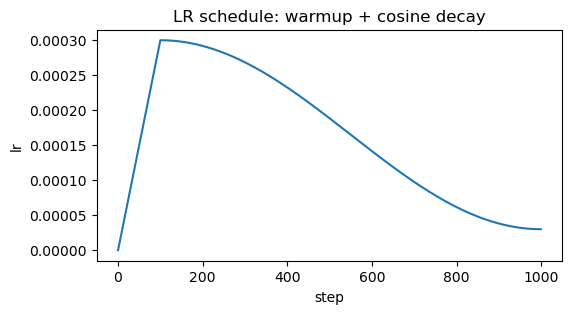

ok: schedule warms up to peak then cosine-decays to floor


In [10]:
# check -- shape of the schedule must be: rises to peak, then falls to floor
import matplotlib.pyplot as plt
_steps = range(0, 1000)
_lrs = [get_lr(s, warmup=100, max_steps=1000) for s in _steps]
assert abs(_lrs[0]) < 1e-9, "warmup must start at lr=0"
assert abs(_lrs[100] - 3e-4) < 1e-9, "lr should peak at max_lr right after warmup"
assert _lrs[100] > _lrs[500] > _lrs[999], "lr must decay after warmup"
assert abs(_lrs[999] - 3e-5) < 1e-6, "lr should land at min_lr"
plt.figure(figsize=(6, 3)); plt.plot(_steps, _lrs)
plt.title("LR schedule: warmup + cosine decay"); plt.xlabel("step"); plt.ylabel("lr"); plt.show()
print("ok: schedule warms up to peak then cosine-decays to floor")

## 5. Training loop with checkpoint save/resume

Now we assemble: get a batch → set this step's LR → AMP train step → occasionally evaluate and **save a checkpoint**.

**Gradient accumulation (the trick that fakes a big batch).** Big batches train more stably, but a big batch may not fit in VRAM. Accumulation runs several *micro-batches*, summing their gradients, and only steps the optimizer once. Effective batch = `micro_batch × accum_steps` — at the memory cost of *one* micro-batch.
> *ponytail: start with `accum_steps=1`. Add accumulation only if training is visibly unstable or you specifically want a larger effective batch — it's free stability but it slows wall-clock per optimizer step.* We keep the loop simple (no accumulation) and leave it as a noted lever.

**What a checkpoint must contain to truly resume.** Not just the weights — also the optimizer state (Adam's moments) and the step counter. Miss the optimizer state and you restart Adam cold; miss the step and your LR schedule jumps.

| saved key | why |
|---|---|
| `model` | the weights (the actual product) |
| `optimizer` | Adam's running moment estimates — drop these and the first resumed steps lurch |
| `step` | so `get_lr(step)` and the loop continue from the right place |
| `cfg` | so you can rebuild the exact architecture before loading weights |

| loop variable | meaning |
|---|---|
| `max_steps` | total optimizer steps to run |
| `eval_interval` | how often to measure val loss + save |
| `loss_history` | per-step train loss, for the curve (like Ch.2) |

In [11]:
def save_ckpt(path, model, optimizer, step):
    # getattr unwraps a torch.compile() wrapper: a compiled model's state_dict() prefixes every
    # key with "_orig_mod.", which would fail to load into the plain GPT in 3b. Save the raw module.
    raw = getattr(model, "_orig_mod", model)
    torch.save({"model": raw.state_dict(),
                "optimizer": optimizer.state_dict(),
                "step": step,
                "cfg": raw.cfg}, path)


def load_ckpt(path, map_location=device):
    """Returns (model, optimizer_state, step). Rebuilds the model from the saved cfg."""
    ckpt = torch.load(path, map_location=map_location, weights_only=False)
    m = GPT(ckpt["cfg"]).to(map_location)
    m.load_state_dict(ckpt["model"])
    return m, ckpt["optimizer"], ckpt["step"]


@torch.no_grad()
def estimate_loss(model, data, block_size, batch_size, iters=20):
    """Average loss over a few random batches (eval mode). A cheap val-loss proxy."""
    model.eval()
    losses = []
    for _ in range(iters):
        x, y = get_batch(data, block_size, batch_size)
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            _, loss = model(x, y)
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)

In [12]:
import threading
import queue
from tqdm.auto import tqdm

# Prompts we re-generate from at every eval point so you can WATCH the model go
# gibberish -> real words -> grammatical fragments -> coherent text as loss falls.
SAMPLE_PROMPTS = ["The mitochondria is", "In 1969, astronauts", "Water boils at"]


class BatchPrefetcher:
    """A background thread that keeps `get_batch` results ready so the GPU never waits on the
    CPU. One thread is enough: numpy slicing, the uint16->int64 cast, pin_memory(), and the
    async H2D copy all release the GIL, so they overlap with GPU compute. We deliberately avoid
    a multiprocessing DataLoader -- worker spawn/pickling is painful on Windows and overkill for
    a memmap this small. Producer and consumer share the default CUDA stream, so a copy enqueued
    here is ordered before the training kernels that consume it (no race)."""
    def __init__(self, data, block_size, batch_size, depth=4):
        self.data, self.block_size, self.batch_size = data, block_size, batch_size
        self.q = queue.Queue(maxsize=depth)
        self._stop = False
        self.t = threading.Thread(target=self._worker, daemon=True)
        self.t.start()

    def _worker(self):
        while not self._stop:
            try:
                self.q.put(get_batch(self.data, self.block_size, self.batch_size), timeout=0.5)
            except queue.Full:
                continue

    def get(self):
        return self.q.get()

    def close(self):
        self._stop = True


def train(model, optimizer, data, *, max_steps, batch_size,
          eval_interval=200, sample_prompts=SAMPLE_PROMPTS,
          ckpt_path=None, start_step=0, max_lr=3e-4, min_lr=3e-5, warmup=100):
    """Full pretraining loop. Returns a history dict of per-step metrics:
       {"step", "loss", "lr", "grad_norm", "batch_time", "vram_gb"}  (x-axis = step)
       plus {"val_step", "val_loss"}                                 (measured every eval_interval).
    A tqdm bar shows live loss / lr / grad-norm / ms-per-step / tok-per-sec / VRAM + ETA.
    At every eval point it measures val loss AND generates from `sample_prompts`.
    """
    history = {"step": [], "loss": [], "lr": [], "grad_norm": [], "batch_time": [], "vram_gb": [],
               "val_step": [], "val_loss": []}
    # `base` is the underlying module (shares params with the torch.compile wrapper, if any).
    # Use it for eval + generation: variable-length sampling on the compiled model would force
    # a recompile per sequence length. Training uses `model` (compiled) with a fixed shape.
    base = getattr(model, "_orig_mod", model)
    model.train()
    if device == "cuda":
        torch.cuda.reset_peak_memory_stats()
    prefetch = BatchPrefetcher(data, base.block_size, batch_size) if device == "cuda" else None
    pbar = tqdm(range(start_step, max_steps), initial=start_step, total=max_steps,
                desc="pretrain", dynamic_ncols=True)
    try:
        for step in pbar:
            t_step = time.time()

            # 1. set this step's LR (PyTorch optimizers don't schedule themselves)
            lr = get_lr(step, max_lr, min_lr, warmup, max_steps)
            for g in optimizer.param_groups:
                g["lr"] = lr

            # 2-3. batch (from the prefetcher's queue) -> AMP train step (returns pre-clip grad norm)
            x, y = prefetch.get() if prefetch else get_batch(data, base.block_size, batch_size)
            loss, grad_norm = train_step(model, optimizer, x, y)

            dt = time.time() - t_step      # train_step's loss.item() already drained the GPU -> dt is real
            vram = torch.cuda.max_memory_allocated() / 1e9 if device == "cuda" else 0.0

            # 4. record per-step metrics (keyed by the real step, so plots line up after a resume)
            history["step"].append(step)
            history["loss"].append(loss)
            history["lr"].append(lr)
            history["grad_norm"].append(grad_norm)
            history["batch_time"].append(dt)
            history["vram_gb"].append(vram)

            # live bar: rolling avg step time + throughput (tqdm appends the ETA itself)
            avg_dt = sum(history["batch_time"][-50:]) / len(history["batch_time"][-50:])
            tok_s = batch_size * base.block_size / avg_dt
            pbar.set_postfix(loss=f"{loss:.3f}", lr=f"{lr:.1e}", gnorm=f"{grad_norm:.2f}",
                             ms=f"{avg_dt*1e3:.0f}", tok_s=f"{tok_s:,.0f}", vram=f"{vram:.1f}G")

            # 5. periodic eval -> val loss + checkpoint + qualitative samples (all on `base`)
            if step % eval_interval == 0 or step == max_steps - 1:
                val = estimate_loss(base, data, base.block_size, batch_size)
                history["val_step"].append(step)
                history["val_loss"].append(val)
                tqdm.write(f"step {step:6d} | lr {lr:.2e} | train {loss:.3f} | val {val:.3f} "
                           f"| gnorm {grad_norm:.2f} | {avg_dt*1e3:.0f} ms/step "
                           f"| {tok_s:,.0f} tok/s | vram {vram:.2f} GB")
                if ckpt_path:
                    save_ckpt(ckpt_path, model, optimizer, step)
                if sample_prompts:
                    for p in sample_prompts:
                        tqdm.write(f"   [{step}] {complete(base, p, max_new_tokens=30, temperature=0.7, top_k=50)!r}")
    finally:
        if prefetch:
            prefetch.close()

    pbar.close()
    avg_dt = sum(history["batch_time"]) / len(history["batch_time"])
    print(f"trained {max_steps - start_step} steps | avg {avg_dt*1e3:.0f} ms/step "
          f"| peak vram {max(history['vram_gb']):.2f} GB")
    return history

In [13]:
# check -- overfit a tiny batch (same sanity check as Ch.2): loss must collapse toward ~0.
# If the loop can't memorize ONE batch, the loop itself is broken (not the data, not the model size).
_m = GPT(cfg).to(device)
_opt = torch.optim.AdamW(_m.parameters(), lr=3e-4, betas=(0.9, 0.95))
_data = np.memmap(os.path.join(DATA_DIR, "fineweb_tiny.bin"), dtype=np.uint16, mode="r")
_xb, _yb = get_batch(_data, cfg.block_size, batch_size=4)

_m.train()
for i in range(200):
    # bypass get_batch: reuse the SAME (_xb,_yb) every step so the model can memorize it
    _opt.zero_grad(set_to_none=True)
    with torch.autocast(device_type=device, dtype=torch.bfloat16):
        _, l = _m(_xb, _yb)
    l.backward(); _opt.step()
print(f"overfit loss after 200 steps on one batch: {l.item():.4f}")
assert l.item() < 0.5, "couldn't overfit one batch -- training loop/model wiring is wrong"
print("ok: loop can drive loss down -- machinery works")
del _data

overfit loss after 200 steps on one batch: 0.0014
ok: loop can drive loss down -- machinery works


## 6. Generate from the base model (given)

Identical to Ch.2's sampler — a base model just **continues text**, it doesn't chat (that's 3b). We use it here only to eyeball whether pretraining produced coherent English. Given, not a TODO.

In [14]:
@torch.no_grad()
def generate(model, idx, max_new_tokens, temperature=1.0, top_k=None):
    model.eval()
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.block_size:]
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature
        if top_k is not None:
            v, _ = torch.topk(logits, top_k)
            logits[logits < v[:, [-1]]] = float("-inf")
        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)
    model.train()
    return idx


def complete(model, prompt, max_new_tokens=100, temperature=0.8, top_k=50):
    ids = torch.tensor([enc.encode_ordinary(prompt)], device=device)
    out = generate(model, ids, max_new_tokens, temperature, top_k)
    return enc.decode(out[0].tolist())

## 7. The real pretraining run

Now the actual thing. Steps:

1. **Build the real token cache.** Pick a budget. `200M` tokens (~400MB) is a sensible *first* real run — finishes in well under an hour and already gives readable English. Bump to 1–2B once you trust the pipeline. (FineWeb-Edu streaming + tokenizing ~200M tokens is the slow part; it's cached after the first time.)
2. **Pick batch size for your 8GB.** Start at `batch_size=24`, watch the peak-VRAM print from the Phase-3 check. If it OOMs: drop batch size, *then* flip `model.use_checkpoint = True` if you still need room.
3. **Train.** With `max_steps`, set `warmup ≈ 5%` of steps and `max_steps` so you do a few passes over the data.

> **Sanity expectations:** first loss ≈ `ln(50257) ≈ 10.8`, dropping below ~4 within a few thousand steps; FineWeb-Edu base models settle around ~3.x val loss at this size. Generation should go from gibberish → real words → grammatical fragments → coherent sentences as loss falls.

### What the instrumentation tells you (read the bar + the dashboard)

The loop tracks per-step `loss / lr / grad_norm / batch_time / vram` (x-axis = real step, so it stays correct after a resume) and `val_loss` at each eval. The dashboard plots four panels; how to read them:

| signal | healthy | warning sign |
|---|---|---|
| **train vs val loss** | both fall together, smoothly | val flattens/rises while train keeps dropping → overfitting; train flat from step 0 → LR too low or data broken; either explodes → init/LR bug |
| **grad norm** (pre-clip, log axis) | high on step 1, settles to a low steady band | frequent spikes to 10–100× → unstable (lower `max_lr` or add grad accumulation); pinned at the clip ceiling every step → clipping is masking an LR that's too high |
| **VRAM** | flat after warmup | creeping up → a leak (you're holding tensors with grad); near 8 GB → drop batch size before it OOMs |
| **step time / tok/s** | flat | rising → thermal throttling or other GPU load; the **ETA** in the tqdm bar = `remaining_steps × avg_step_time` |
| **samples** (at each eval) | gibberish → words → fragments → sentences | still gibberish late → loss isn't actually falling; verify the curve |

The tqdm bar shows all of `loss / lr / gnorm / ms / tok_s / vram` live plus a wall-clock **ETA**; at each `eval_interval` the loop writes the `step … | val …` line **and** generates from `sample_prompts`, all above the bar so you get both the live view and a scrollback log.

> **ponytail: this cell is *given* scaffolding (config + run + plot), not a TODO — orchestration and plotting are tooling, not the learning target. The learning was in Phases 1–5. Tune the numbers to your patience and your VRAM.**

### Making it fast — why the first naive run is GPU-starved, and the four fixes

A 50M model on an 8GB Ada card is **launch-bound, not compute-bound**: each step is many tiny kernels with Python/CPU work between them, so the GPU sits mostly idle (a quick check: `6 × params × tokens` FLOPs ÷ your ms/step often lands at single-digit % of the card's bf16 throughput). The fixes, cheapest first:

| fix | where | why it helps | cost / caveat |
|---|---|---|---|
| **TF32 + `cudnn.benchmark`** | setup cell | TF32 runs matmuls on tensor cores at ~fp32 accuracy; benchmark autotunes kernels for our fixed shapes | one-time autotune on step 1; otherwise free |
| **`BatchPrefetcher`** | `train()` | a background thread runs `get_batch` (slice + cast + pin + H2D copy) *while the GPU computes*, so the GPU never waits on the CPU | one daemon thread; safe because producer/consumer share the default CUDA stream |
| **`torch.compile(model)`** | run cell | fuses the many small kernels into a few and removes per-op launch overhead — the biggest win for a launch-bound model (~1.3–1.7× on Ada) | first step compiles (long pause). **Needs Triton, which isn't bundled on Windows** — the cell detects this and *skips cleanly*; `pip install triton-windows` to enable. State-dict keys get an `_orig_mod.` prefix, which is why `save_ckpt` unwraps it |
| **resume** (`RESUME=True`) | run cell | restores weights **and Adam's moments and the step counter**, so you don't throw away the steps you already paid for | none — but `start_step` must continue the LR schedule (handled) |

Two correctness notes the compile forces: `save_ckpt` strips the `_orig_mod.` prefix (so 3b can load the base), and `train()` runs **eval + generation on the uncompiled module** — variable-length sampling on a compiled model would recompile for every sequence length.

**On Windows without Triton** (the common case): you still get TF32 + the prefetcher automatically. To unlock `torch.compile` too, `pip install triton-windows` and re-run the run cell — there's a matching `triton-windows` line in `requirements.txt` (commented).

**Measure before and after.** Run the profiling cell below once *uncompiled* and once *compiled* to see the data-load vs forward+backward split and confirm the speedup is real — don't trust a guess (including mine).

In [15]:
# profile -- where does a step actually go? data-load vs forward+backward.
# Run this to locate the bottleneck instead of guessing. (Uses a fresh model so it's standalone.)
_data = np.memmap(os.path.join(DATA_DIR, "fineweb_train.bin"), dtype=np.uint16, mode="r")
_m = GPT(cfg).to(device)
_opt = torch.optim.AdamW(_m.parameters(), lr=3e-4)


def _time(fn, iters=30, warmup=5):
    for _ in range(warmup):
        fn()
    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(iters):
        fn()
    if device == "cuda":
        torch.cuda.synchronize()
    return (time.time() - t0) / iters * 1e3   # ms


t_data = _time(lambda: get_batch(_data, cfg.block_size, 24))
_xb, _yb = get_batch(_data, cfg.block_size, 24)
t_step = _time(lambda: train_step(_m, _opt, _xb, _yb))
print(f"get_batch:           {t_data:6.1f} ms   <- CPU/IO; the prefetcher hides this behind compute")
print(f"forward+backward:    {t_step:6.1f} ms   <- GPU; torch.compile shrinks this")
print(f"tok/s if GPU-bound:  {24*cfg.block_size/(t_step/1e3):,.0f}   (vs measured ~11k in the naive run)")
del _data, _m, _opt

get_batch:              4.0 ms   <- CPU/IO; the prefetcher hides this behind compute
forward+backward:     186.2 ms   <- GPU; torch.compile shrinks this
tok/s if GPU-bound:  32,995   (vs measured ~11k in the naive run)


In [16]:
# ---- 1. real token cache (edit TOKEN_BUDGET to taste; ~2 bytes/token on disk) ----
# Chinchilla rule of thumb: ~20 tokens/param. At 51M params that's ~1B tokens for a
# compute-optimal base. 500M is a strong, cheaper middle ground (zero repetition for a 30k run).
# NOTE the path encodes the budget: build_token_cache() skips rebuild if the file exists, so a
# fixed name would silently reuse an old, smaller cache when you raise the budget.
TOKEN_BUDGET = 500_000_000      # 500M tokens ~= 1GB on disk. One-time tokenize cost ~2.5x the 200M build.
real_path = build_token_cache(os.path.join(DATA_DIR, f"fineweb_train_{TOKEN_BUDGET//1_000_000}M.bin"),
                              TOKEN_BUDGET)
data = np.memmap(real_path, dtype=np.uint16, mode="r")
print(f"training data: {len(data):,} tokens")

ckpt = os.path.join(DATA_DIR, "base.pt")

# ---- training horizon -- decide it UP FRONT so the cosine LR schedule is one smooth curve ----
BATCH_SIZE = 32                 # bumped from 24 (you had VRAM headroom). Watch vram=; back off if it nears ~7.5G.
MAX_STEPS  = 30000              # 30k*32*256 ~= 245M tokens consumed (~0.5 epoch of a 500M pool -> all unique).
WARMUP     = int(0.03 * MAX_STEPS)
# Want the full 500M pool? raise MAX_STEPS to ~60000 (~5 h). Full Chinchilla (~1B tokens):
# TOKEN_BUDGET=1_000_000_000 and MAX_STEPS~120000 (~10 h).

# ---- RESUME = continue an INTERRUPTED run of THIS same horizon (crash / closed-lid recovery) ----
# With MAX_STEPS unchanged from the checkpoint's run, get_lr() picks up exactly where it left off
# -> NO LR jump. (Raising MAX_STEPS above the checkpoint's original horizon is a "warm restart":
# the LR steps back up at resume and the loss may briefly spike before recovering -- only do that
# if you deliberately want to extend a run that had already decayed to min_lr.)
RESUME = False                  # set True to continue from data/base.pt instead of starting fresh
torch.manual_seed(1337)
start_step = 0
if RESUME and os.path.exists(ckpt):
    model, opt_state, last_step = load_ckpt(ckpt)               # rebuilds GPT from saved cfg + weights
    start_step = last_step + 1                                  # continue the curve + LR schedule cleanly
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), weight_decay=0.1)
    optimizer.load_state_dict(opt_state)                        # restore Adam's moments (don't restart cold)
    print(f"resumed from step {last_step} -> continuing at {start_step}/{MAX_STEPS}")
    if start_step >= MAX_STEPS:
        print("  NOTE: checkpoint already at/past MAX_STEPS -- raise MAX_STEPS to train further (warm restart).")
else:
    model = GPT(cfg).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), weight_decay=0.1)
# model.use_checkpoint = True    # <- uncomment ONLY if you OOM at your chosen batch size
print(f"params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

# ---- torch.compile -- fuses kernels + cuts launch overhead (~2x measured on your 4060 Ti) ----
# Triton is installed now; this auto-skips cleanly if it ever isn't. First step compiles (long pause).
USE_COMPILE = True


def _triton_available():
    try:
        import triton  # noqa: F401
        return True
    except Exception:
        return False


if USE_COMPILE and device == "cuda" and _triton_available():
    model = torch.compile(model)
    print("torch.compile: on (first step compiles -- expect a long pause, then ~280 ms/step)")
elif USE_COMPILE and device == "cuda":
    print("torch.compile: SKIPPED -- no Triton backend (`pip install triton-windows`). Prefetcher + TF32 still active.")

# ---- 3. train ----
history = train(model, optimizer, data,
                max_steps=MAX_STEPS, batch_size=BATCH_SIZE,
                eval_interval=1000, ckpt_path=ckpt, start_step=start_step,
                max_lr=3e-4, min_lr=3e-5, warmup=WARMUP)

data\fineweb_train_500M.bin already exists (500,000,000 tokens) -- skipping rebuild
training data: 500,000,000 tokens
params: 51.1M
torch.compile: on (first step compiles -- expect a long pause, then ~280 ms/step)


pretrain:   0%|          | 0/30000 [00:00<?, ?it/s]

step      0 | lr 0.00e+00 | train 10.954 | val 10.961 | gnorm 10.34 | 2453 ms/step | 3,340 tok/s | vram 6.21 GB
   [0] 'The mitochondria is virtual conviction 16 sentient issues civ sufficient Ubisoftlining knowingly Commun blink 808 facetbonesOffset formationsTarget team zoifts?????- Daily automation UE ye vessels wel Jacob Cod'
   [0] 'In 1969, astronauts Feminist Surge True majoritiescontOcean albums throwbishop ket Aircraftanwhile\x0fbishop Barry submertyp whit outsetunta fightingifts clusteredixon 16genOffset Manyzu thieves'
   [0] 'Water boils atonian magistrate instances produce produce magistrate CES produce Claud CPS aft sorceKR Combostyles measlesThinkSensor 128PoStorm Switch meticecause Lawson Lawson Lawson splits Towns"-'
step   1000 | lr 3.00e-04 | train 5.953 | val 5.994 | gnorm 1.02 | 410 ms/step | 19,962 tok/s | vram 6.62 GB
   [1000] 'The mitochondria is the present. The first time is a series of an individual, in the other hand, and the difference between the other ha

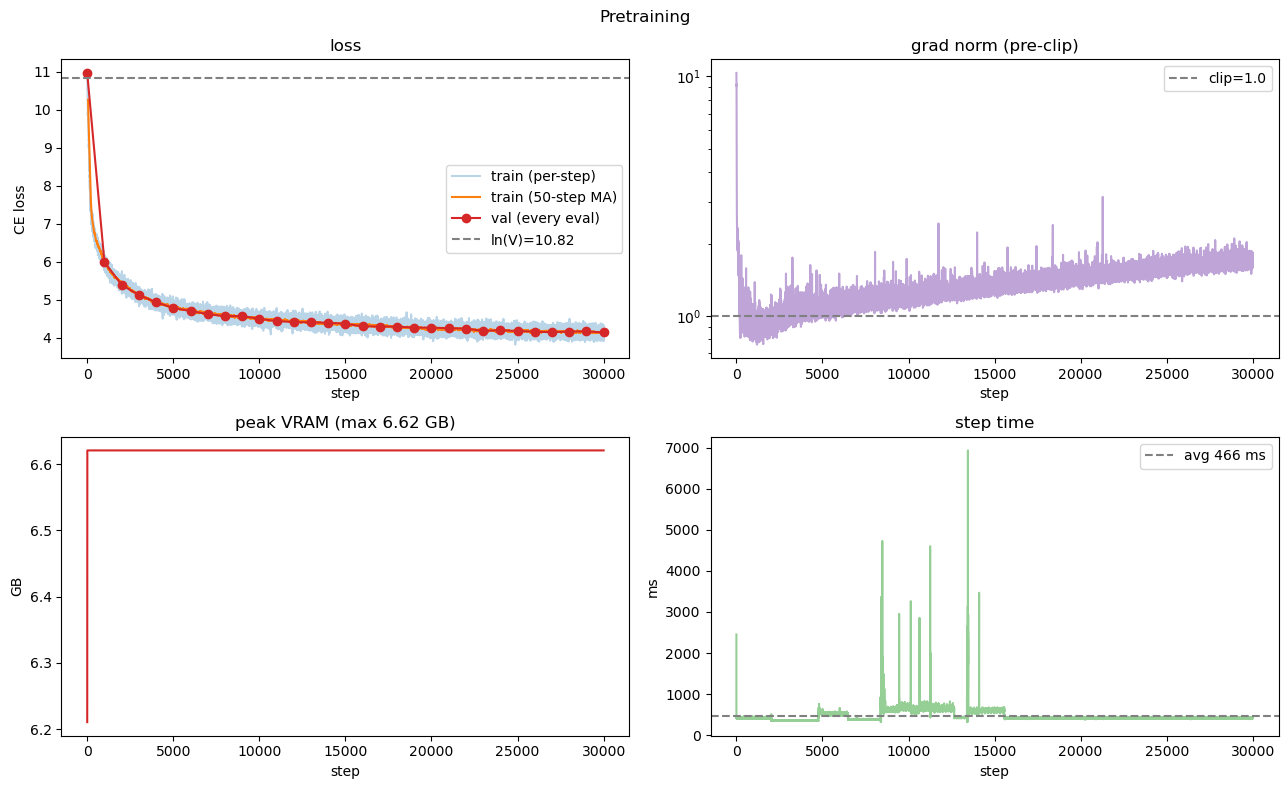

In [17]:
# training dashboard -- loss / grad-norm / VRAM / step-time, all on the real step axis
import numpy as _np


def plot_history(history, title="Pretraining"):
    h = history
    s = h["step"]                       # x-axis = real training step (correct even after a resume)
    fig, ax = plt.subplots(2, 2, figsize=(13, 8))

    # train loss (+50-step MA) + val loss overlay + ln(V) baseline
    ma = _np.convolve(h["loss"], _np.ones(50) / 50, mode="valid")
    ax[0, 0].plot(s, h["loss"], alpha=0.3, label="train (per-step)")
    ax[0, 0].plot(s[49:], ma, label="train (50-step MA)")
    if h["val_step"]:
        ax[0, 0].plot(h["val_step"], h["val_loss"], "o-", color="tab:red", label="val (every eval)")
    ax[0, 0].axhline(math.log(VOCAB_SIZE), ls="--", color="gray", label=f"ln(V)={math.log(VOCAB_SIZE):.2f}")
    ax[0, 0].set_title("loss"); ax[0, 0].set_xlabel("step"); ax[0, 0].set_ylabel("CE loss"); ax[0, 0].legend()

    # grad norm (log scale -- spikes are easier to see) + the clip ceiling
    ax[0, 1].semilogy(s, h["grad_norm"], color="tab:purple", alpha=0.6)
    ax[0, 1].axhline(1.0, ls="--", color="gray", label="clip=1.0")
    ax[0, 1].set_title("grad norm (pre-clip)"); ax[0, 1].set_xlabel("step"); ax[0, 1].legend()

    # peak VRAM
    ax[1, 0].plot(s, h["vram_gb"], color="tab:red")
    ax[1, 0].set_title(f"peak VRAM (max {max(h['vram_gb']):.2f} GB)")
    ax[1, 0].set_xlabel("step"); ax[1, 0].set_ylabel("GB")

    # per-step time in ms
    avg_ms = 1e3 * sum(h["batch_time"]) / len(h["batch_time"])
    ax[1, 1].plot(s, [t * 1e3 for t in h["batch_time"]], color="tab:green", alpha=0.5)
    ax[1, 1].axhline(avg_ms, ls="--", color="gray", label=f"avg {avg_ms:.0f} ms")
    ax[1, 1].set_title("step time"); ax[1, 1].set_xlabel("step"); ax[1, 1].set_ylabel("ms"); ax[1, 1].legend()

    fig.suptitle(title); plt.tight_layout(); plt.show()


plot_history(history)

In [18]:
# eyeball the base model -- it should CONTINUE text coherently (not chat)
for p in ["The mitochondria is", "In 1969, astronauts", "To make a paper airplane, first"]:
    print(repr(complete(model, p, max_new_tokens=40, temperature=0.7, top_k=50)))
    print()

'The mitochondria is the main source of energy. The power of the energy in the body is the energy used to store energy. They are the energy used to store energy in the body. In order to make the energy'

'In 1969, astronauts from the Soviet Union and the Soviet Union were expected to join forces in the Soviet Union, but it was not until the early 1970s that the Soviet Union would continue to play a significant role in the'

'To make a paper airplane, first go to the air station.\nTo finish the flight, start with the ball and then press the air station.\nThis is the first time that the flying aircraft has arrived.\nNow, take'



In [31]:
print(repr(complete(model, "The capital of France is", max_new_tokens=40, temperature=0.7, top_k=50)))

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


## Done — base model trained and checkpointed

You now have `data/base.pt`: a ~50M GPT that has read real English and can continue text coherently. It is **not** an assistant yet — ask it a question and it'll just keep writing web text.

**→ Chapter 3b** loads this checkpoint and SFTs it into a chat model: chat templates, **loss masking** (the core new idea), the SFT data pipeline on Dolly-15k, and chat-style generation.

**Knobs you can come back and turn** (none change the concepts):
- `TOKEN_BUDGET` ↑ (more data = better base), `MAX_STEPS` ↑
- `cfg.d_model / n_layers` ↑ toward ~100M if VRAM allows
- `model.use_checkpoint = True` if you OOM when scaling up

# Appendix — the whole machine, end to end (granular)

A map of everything that happens, where each optimization lives, and the exact shapes/dtypes/bytes as data moves. Constants for this run: `B=32` (batch), `T=256` (block_size), `d=512` (d_model), `H=8` heads × `d_k=64`, `d_ff=2048`, `V=50257` (vocab), `L=8` layers, `params≈51M`.

---

## A. The data path — from disk to a GPU tensor (once per step, hidden behind compute)

```
 DISK                          CPU (RAM)                              GPU (VRAM, 8GB)
 ─────────────────────────     ──────────────────────────────────    ───────────────────────────
 fineweb_train_500M.bin        ┌─ get_batch() runs in a BG thread ─┐
 1,000,000,000 bytes           │  (BatchPrefetcher, GIL released)  │
 = 500M tokens × uint16        │                                   │
        │                      │ 1. ix = randint(N-T-1, (B,))      │
        │  np.memmap           │      → B random start offsets     │
        │  (lazy: OS pages in  │                                   │
        │   only touched 512B  │ 2. for each i: data[i:i+T]        │
        ▼   slices)            │      uint16 window  (B×T×2 = 16KB) │
   ┌──────────┐                │      .astype(int64)  → B×T×8 =131KB│   non_blocking=True
   │ 512B-ish │  page fault    │    x = stack(...)  y = stack(+1)   │   on default stream
   │  slices  │ ───────────────▶ 3. x.pin_memory()  (page-locked)  │ ──H2D copy──▶ x:(B,T) int64
   └──────────┘                │ 4. x.to('cuda', non_blocking)     │              y:(B,T) int64
                               └───────────────────────────────────┘              ~262 KB total
```

- **Why uint16 on disk:** max token id 50256 < 65536, so 2 bytes/token. int64 would 4× the file. We pay the cast to int64 *late*, on the CPU, only for the 16 KB we actually touch.
- **Why memmap:** the file (1 GB at 500M) is never fully loaded; the OS pages in only the random 512-byte windows each `data[i:i+T]` touches. A 10 GB cache would "fit in RAM" the same way.
- **Why pin + non_blocking:** a page-locked (pinned) host buffer lets the GPU DMA the copy *asynchronously* and overlap it with compute. Pageable memory would force a synchronous staged copy.
- **Why a background thread:** measured `get_batch ≈ 0.5 ms`, `forward+backward ≈ 147 ms`. The prefetcher runs that 0.5 ms on another thread so it's fully hidden — the GPU never waits on the CPU. (numpy/pin/copy all release the GIL.)

---

## B. One training step — the granular timeline (`train()` loop body, ×30000)

```
step N
 │
 ├─ lr = get_lr(N)                         cosine-with-warmup → write into optimizer.param_groups
 │
 ├─ x,y = prefetch.get()                   (already on GPU; see path A — ~0 wait)
 │
 ├─ train_step(model, opt, x, y):          ◄── the compiled hot path
 │     ├ optimizer.zero_grad(set_to_none=True)     drop old .grad tensors (free, less memory)
 │     ├ with autocast(bf16):                       ┐ matmuls in bf16, softmax/norm stay fp32
 │     │     logits, loss = model(x, y)             ┘ (forward — see C)
 │     ├ loss.backward()                            autograd walks the graph → .grad for every param (D)
 │     ├ grad_norm = clip_grad_norm_(…, 1.0)        global L2 norm; rescale if > 1.0  (also logged)
 │     └ optimizer.step()                           AdamW update using (grad, m, v)   (D)
 │
 ├─ dt = now - t0                           loss.item() already synced the GPU → dt is real wall-time
 ├─ vram = max_memory_allocated()
 ├─ history[...].append(...)                step / loss / lr / grad_norm / batch_time / vram
 ├─ pbar.set_postfix(...)                   live: loss lr gnorm ms tok/s vram  + ETA
 │
 └─ if N % eval_interval == 0:              every 1000 steps:
       ├ val = estimate_loss(base)          20 no-grad forward batches, eval mode  (UNcompiled `base`)
       ├ save_ckpt(base, opt, N)            weights + Adam moments + step + cfg  → base.pt
       └ for p in SAMPLE_PROMPTS:           generate 30 tokens (see E) — watch quality climb
             complete(base, p)
```

The optimizer **state** that persists across steps (not freed): `param` (fp32) + `param.grad` (fp32) + Adam `m` + Adam `v` ≈ `51M × 4 × 4 ≈ 0.82 GB`. Everything else (activations) is born and freed each step.

---

## C. The forward pass — inside `GPT.forward` (shapes at every hop)

```
idx (B,T) int64 ─ token ids
   │
   │  wte[idx]        embedding lookup        → (B,T,d)        gather rows of a (V,d) table
   │  + wpe[0:T]      positional embedding    → (B,T,d)        add learned position vectors
   ▼
   x (B,T,512)  ──────────────────────────────────────────────┐
   │                                                           │  ×8 Blocks (pre-norm residual)
   │   ┌─ ln1 → CausalSelfAttention ─────────────┐             │
   │   │     qkv: Linear 512→1536, split q,k,v    │            │
   │   │     reshape → (B,8,T,64) per head        │            │
   │   │     SDPA(q,k,v, is_causal=True)          │  Flash-attn kernel: softmax(QKᵀ/√d_k)·V,
   │   │        → (B,8,T,64) → (B,T,512)          │  causal mask, never builds the full T×T in HBM
   │   │     out_proj: Linear 512→512             │            │
   │   x = x + attn(ln1(x))   ◄ residual add      ┘            │
   │   ┌─ ln2 → MLP ─────────────────────────────┐            │
   │   │     mlp_fc: 512→2048, GELU, mlp_proj 2048→512         │
   │   x = x + mlp(ln2(x))    ◄ residual add      ┘            │
   └───────────────────────────────────────────────────────────┘
   ▼
   ln_f(x)                       final layernorm     → (B,T,512)
   lm_head(x)                    Linear 512→50257    → (B,T,50257)   logits  (weight-TIED to wte)
   │
   └─ loss = cross_entropy(logits.view(B*T,V), y.view(B*T), ignore_index=-100)   → scalar
```

- **Next-token objective:** position `t`'s logits predict token `t+1` (= `y[t]`). One (B,T) batch yields `B×T = 8192` prediction targets at once.
- **Weight tying:** `lm_head.weight is wte.weight` — the (50257×512) table is shared as both input embedding and output projection. Saves ~25M params and ties their gradients.
- **`-100` masking:** harmless here (no -100 in pretraining) but it's the *same* `ignore_index` that powers loss-masking in 3b.

---

## D. Backward + update — how weights actually change

```
loss.backward()
   │   autograd replays the forward graph in reverse, filling p.grad for all ~51M params.
   │   This is the memory-heavy half: every saved activation from C is held until its grad is used.
   ▼
clip_grad_norm_(params, 1.0)
   │   g_total = sqrt(Σ ‖p.grad‖²).  if g_total > 1.0:  p.grad *= 1.0 / g_total   (for all p)
   │   → caps a single bad batch from lurching the weights. We log g_total as the health signal.
   ▼
AdamW.step()   (per parameter, fused CUDA kernel)
   m = β1·m + (1-β1)·g                 # 1st moment  (β1=0.90)
   v = β2·v + (1-β2)·g²                # 2nd moment  (β2=0.95)
   p -= lr · m̂ / (√v̂ + ε)             # bias-corrected step
   p -= lr · wd · p                    # decoupled weight decay (wd=0.1)  ← the "W" in AdamW
```

---

## E. Generation — how text comes out (inference, `complete`/`generate`)

Autoregressive, one token at a time — **no targets, no backward, `@torch.no_grad`, eval mode**:

```
prompt "The mitochondria is" ─ enc.encode_ordinary ─► ids (1, P)
loop max_new_tokens:
   idx_cond = ids[:, -T:]                       # never exceed block_size
   logits,_ = model(idx_cond)                   # forward (C), but we only want the LAST position
   logits   = logits[:, -1, :] / temperature    # (1, V)   temperature<1 sharpens, >1 flattens
   top-k filter: keep 50 largest, set rest -inf  # cut the long improbable tail
   probs    = softmax(logits)                    # (1, V)
   next_id  = multinomial(probs, 1)              # SAMPLE (not argmax) → varied text
   ids      = cat([ids, next_id], dim=1)         # append, repeat
decode(ids) ─► text
```

Why this is *slow* relative to training: each new token is a full forward over the growing context, and the steps are **serial** (token t+1 needs token t). That's also why we run sampling on the **uncompiled** `base` — the sequence length changes every iteration, which would force `torch.compile` to recompile each step.

---

## F. The optimization stack — what each fix targets

| layer | optimization | bottleneck it removes | measured effect here |
|---|---|---|---|
| **dtype** | bf16 autocast (AMP) | activation memory + matmul speed | ~½ activation memory; tensor-core matmuls; no GradScaler (bf16 has fp32 range) |
| **dtype** | TF32 matmul + `cudnn.benchmark` | fp32 matmul throughput | free tensor-core speedup at ~fp32 accuracy |
| **graph** | `torch.compile` (Inductor+Triton) | per-op kernel **launch overhead** (model is launch-bound, not FLOP-bound) | `fwd+bwd 212→147 ms`; tok/s ~11k → ~28–42k (~2×) |
| **attention** | `F.scaled_dot_product_attention` (Flash) | the T×T attention matrix in HBM | never materializes (B,H,T,T); O(T) memory not O(T²) |
| **data** | `BatchPrefetcher` thread | GPU waiting on CPU/IO | hides the 0.5 ms `get_batch` behind compute |
| **data** | uint16 + memmap | disk size + RAM | 2 B/token; only touched slices paged in |
| **transfer** | pinned + `non_blocking` H2D | sync host→device copy | DMA overlaps compute on the default stream |
| **memory (lever)** | gradient checkpointing (`use_checkpoint`) | activation memory when you OOM | trades ~30% compute to recompute activations in backward |
| **stability** | LR warmup→cosine, grad-clip 1.0 | early divergence / bad-batch spikes | smooth loss; grad-norm stays in a low band |
| **throughput** | bigger `BATCH_SIZE` (24→32) | GPU under-utilization | more tokens/step within the 8 GB budget |

---

## G. The 8 GB budget — what lives in VRAM during a step

```
┌─ persistent across steps (~0.8 GB) ───────────────────────────────┐
│  params (fp32) 0.20 │ grads (fp32) 0.20 │ Adam m 0.20 │ Adam v 0.20│   51M × 4 B each
├─ per-step, born in forward & freed after backward (the variable cost)─┤
│  activations: ∝ B × T × d × L   ← this is what batch size moves     │
├─ one-time ─────────────────────────────────────────────────────────┤
│  CUDA context + cuDNN/Triton kernels + compile workspace            │
└─────────────────────────────────────────────────────────────────────┘
   measured peak this run: ~6.2 GB at B=32  →  ~1.8 GB headroom
```

**One-line mental model:** *random uint16 windows are paged from disk on a side thread, cast and DMA'd to the GPU as int64; a bf16, Flash-attention, kernel-fused forward turns them into next-token logits; cross-entropy + autograd produce gradients; clip + AdamW nudge 51M fp32 weights; repeat 30000× while a cosine LR rises then falls — and every "optimization" above is just removing one specific thing the GPU was waiting on.*